In [2]:
from tqdm import tqdm
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [3]:
from data import DicomDataset, split
np.random.seed(42)

# Exploring the Dataset

In [4]:
root_dir = Path('/data/vision/polina/users/marcusbl/data')

In [5]:
stack_info = [] # dict of {total: #, pos: #, neg: #}
person_info = [] # dict of {stacks_cnt: #}
for person_path in tqdm(list(Path(root_dir).iterdir()), "Loading People Data: "):

    for stack_path in (person_path).iterdir():
        info_dir = stack_path / 'clean'

        # 1) Load Labels
        with open(info_dir / 'labels.json', 'r') as f:
            label_map: dict = json.load(f) # scan_num -> label

        # 2) Get Dicoms, Niftis, Masks (Width, Height, Scans)
        dicom_stack_path = info_dir / 'dicoms.npy'
        nifti_stack_path = info_dir / 'niftis.npy'
        mask_stack_path  = info_dir / 'masks.npy'
        
        pos_count = np.sum(list(label_map.values())).item()
        stack_info.append(
            {
                "total": len(label_map),
                "pos": pos_count, 
                "neg": len(label_map) - pos_count,
            }
        )
    
    person_info.append({"stack_cnt": len(list(((person_path).iterdir())))})

Loading People Data: 100%|██████████| 30/30 [00:00<00:00, 75.74it/s]


## Person Info

,stack_cnt
count,30.000000
mean,10.233333
std,5.556502
min,1.000000
25%,6.000000
50%,8.500000
75%,14.000000
max,23.000000


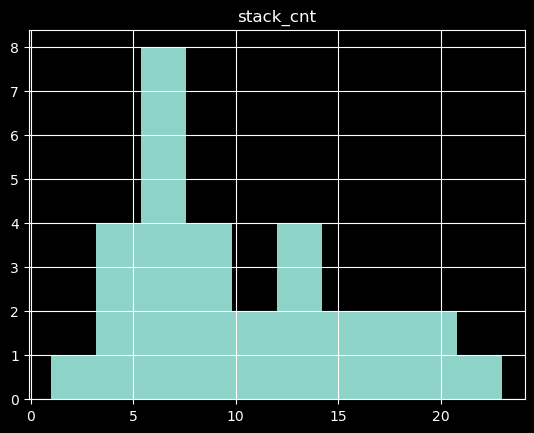

In [6]:
person_df = pd.DataFrame(person_info)
person_df.hist()
person_df.describe()

## Stack Info

There are a total of 8521 scans


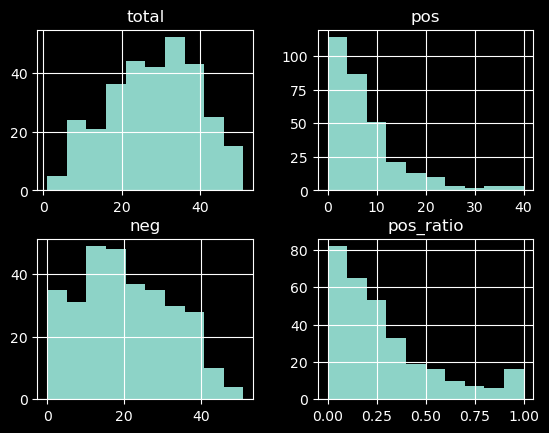

In [7]:
stack_df = pd.DataFrame(stack_info)
stack_df['pos_ratio'] = stack_df['pos'] / stack_df['total']
stack_df.hist()
stack_df

print(f"There are a total of {sum(stack_df['total'])} scans")

In [8]:
stack_df.describe()

,total,pos,neg,pos_ratio
count,307.000000,307.000000,307.000000,307.000000
mean,27.755700,7.019544,20.736156,0.278117
std,11.294437,7.270201,12.066757,0.261516
min,1.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,12.000000,0.083333
50%,28.000000,5.000000,20.000000,0.200000
75%,36.000000,9.000000,30.000000,0.384615
max,51.000000,40.000000,51.000000,1.000000


# Exploring Normalization Techniques

In [9]:
def get_idx(dataset: DicomDataset):
    idx = np.random.randint(low=0, high = 1000)
    if idx in dataset.get_scans_without_mask():
        idx = get_idx(dataset)
    
    return idx

In [10]:
def display_datasets(dataset: DicomDataset, norm_params: list[dict], sup_title: str, fpath: Path | None = None, n: int = 10):
    idxs = np.array([955] + [get_idx(dataset) for _ in range(n-1)])

    fig, ax = plt.subplots(
        nrows=len(idxs)+1, 
        ncols=len(norm_params), 
        figsize=(5 * len(norm_params), 3 * (len(idxs) + 1))  # Increased factors for larger plots
    )
    
    # Set column titles
    for j, params in enumerate(norm_params):
        ax[0, j].set_title(params['title'], fontsize=12)

    # Plot images
    for row, idx in enumerate(idxs):
        for col, p in enumerate(norm_params):
            dataset.set_norm(mask_method = p['mask_method'], norm_method=p['norm_method'], 
                             masked_norm=p['masked_norm'], perc_norm=p['perc_norm'])
            ax[row, col].imshow(dataset[idx][0][0], cmap='gray')

            ax[row, col].set_xticks([])
            ax[row, col].set_yticks([])

        # Row labels on the leftmost column
        ax[row, 0].set_ylabel(f"Idx = {idx};\n Label = {dataset[idx][1]}", rotation=0, size='large', labelpad=40, va='center')


    # Plot histograms in the last row
    for j, p in enumerate(norm_params):
        dataset.set_norm(mask_method = p['mask_method'], norm_method=p['norm_method'], 
                    masked_norm=p['masked_norm'], perc_norm=p['perc_norm'])
        ax[-1, j].hist(dataset[idxs[0]][0][0].flatten(), bins=50, color='gray')
        ax[-1, j].set_xlabel('Pixel value')
        ax[-1, j].set_ylabel('Count')
        ax[-1, j].set_title(f"Hist for Idx = {idxs[0]}")

    fig.suptitle(sup_title, fontsize=20, weight='bold', y=1.02)

    plt.tight_layout()
    plt.subplots_adjust(left=0.15)

    if fpath is not None:
        fig.savefig(fpath)
    plt.show()


In [11]:
dataset = DicomDataset(root_dir)
norm_params = [
    {'mask_method': None, 'norm_method':'min-max', 'masked_norm': False, 'perc_norm': 0.02, 'title': 'min-max (prec=0.02)'},
    {'mask_method': None, 'norm_method':'peak-squash', 'masked_norm': False, 'perc_norm': 0.02, 'title': 'peak squash'},
    {'mask_method': None, 'norm_method':'min-max', 'masked_norm': False, 'perc_norm': 0, 'title': 'min-max'},
    {'mask_method': None, 'norm_method':'peak-squash', 'masked_norm': True, 'perc_norm': 0.02, 'title': 'peak squash (masked)'},
    {'mask_method': None, 'norm_method':'min-max', 'masked_norm': True, 'perc_norm': 0, 'title': 'min-max (masked)'},
    {'mask_method': None, 'norm_method':'min-max', 'masked_norm': True, 'perc_norm': 0.02, 'title': 'min-max (prec=0.02; masked)'},
    {'mask_method': None, 'norm_method':'min-max', 'masked_norm': True, 'perc_norm': 0.01, 'title': 'min-max (prec=0.01; masked)'},

]

Loading People Data:   0%|          | 0/30 [00:00<?, ?it/s]

Loading People Data: 100%|██████████| 30/30 [00:00<00:00, 74.18it/s] 


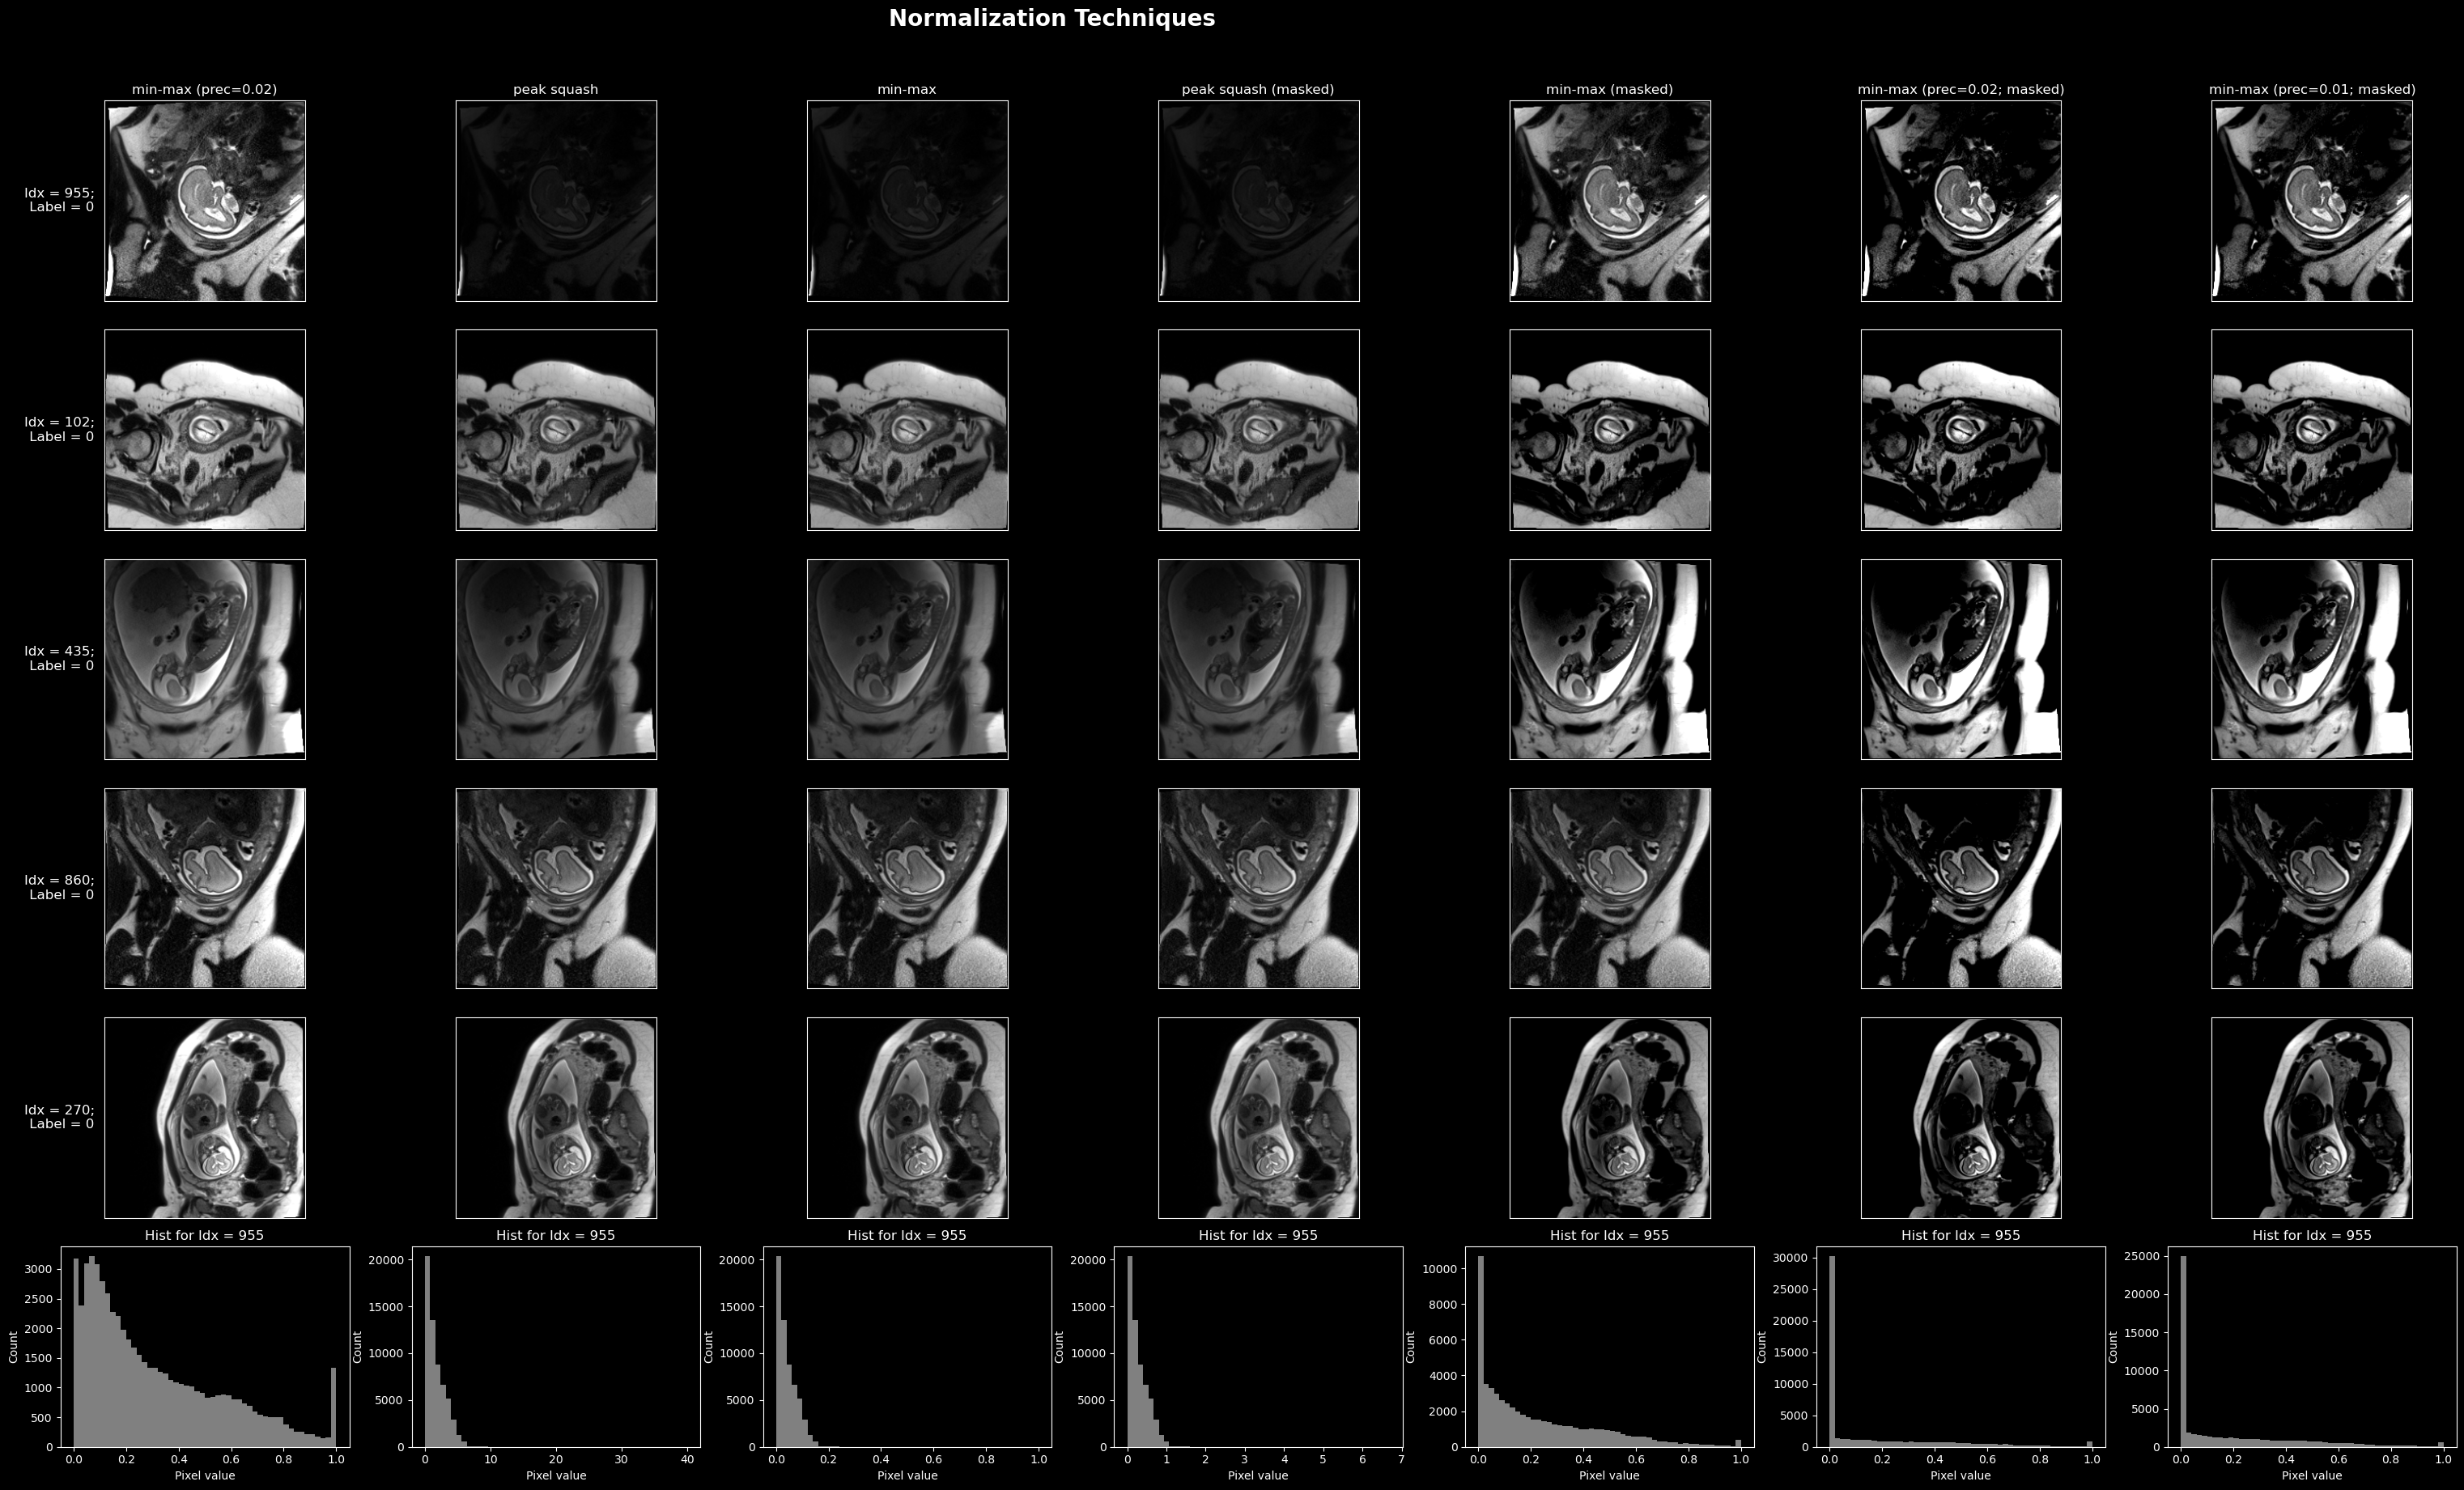

In [12]:
display_datasets(
    dataset = dataset,
    norm_params = norm_params,
    sup_title = 'Normalization Techniques',
    n = 5,
    fpath = Path('../normalization.png')
)

# Figuring out Peak Squash

In [13]:
dataset.set_norm()
no_norm = dataset[955][0][0]
dataset.set_norm(mask_method = None, norm_method = 'peak-squash', masked_norm=False)
no_mask = dataset[955][0][0]
dataset.set_norm(mask_method = None, norm_method = 'peak-squash', masked_norm=True)
yes_mask = dataset[955][0][0]

tensor(37.4814)


''

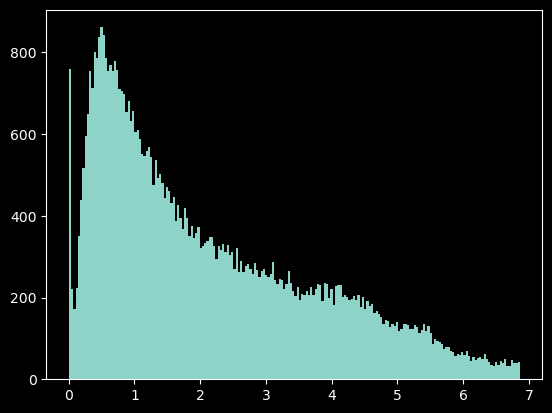

In [14]:
nz_values = no_norm.flatten()

lower = torch.quantile(nz_values, .02)
upper = torch.quantile(nz_values, 1 - .02)

mask = (no_norm > lower) & (no_norm < upper)
no_norm = no_norm[mask]
nz_values = no_norm.flatten()

counts, bin_edges = torch.histogram(nz_values, bins=200)
peak_bin_index = torch.argmax(counts)
x_peak = (bin_edges[peak_bin_index] + bin_edges[peak_bin_index + 1]) / 2


print(x_peak)
plt.hist((no_norm / (2 * x_peak)).flatten(), bins = 200)
""

In [15]:
no_mask / yes_mask

tensor([[   nan,    nan,    nan,  ..., 5.9704, 5.9704, 5.9704],
        [   nan,    nan,    nan,  ..., 5.9704, 5.9704, 5.9704],
        [   nan,    nan,    nan,  ..., 5.9704, 5.9704, 5.9704],
        ...,
        [5.9704, 5.9704, 5.9704,  ..., 5.9704, 5.9704, 5.9704],
        [5.9704, 5.9704, 5.9704,  ..., 5.9704, 5.9704, 5.9704],
        [   nan, 5.9704, 5.9704,  ..., 5.9704, 5.9704, 5.9704]])

# Exploring Augmentations

In [16]:
    # def save_examples(self, dir_path: Path, num_examples: int = 3, num_augs: int = 5):
    #     dir_path.mkdir(parents=True, exist_ok=True)

    #     ncols = num_augs + 1  # base + augmentations
    #     nrows = num_examples

    #     _, axes = plt.subplots(
    #         nrows=nrows, ncols=ncols, figsize=(3 * ncols, 4 + 3 * nrows)
    #     )

    #     base_idxs = np.random.randint(0, len(self), size = num_examples)

    #     for row, base_idx in enumerate(base_idxs):
    #         # Base image (no augmentation)
    #         self.use_transform = False
    #         base_img, base_label = self[base_idx]

    #         # Augmented images
    #         self.use_transform = True
    #         aug_imgs = [self[base_idx][0] for _ in range(num_augs)]

    #         # Collect
    #         all_imgs = [base_img] + aug_imgs
    #         titles = ["base"] + [f"aug {i}" for i in range(num_augs)]

    #         for col, (img, title) in enumerate(zip(all_imgs, titles)):
    #             ax = axes[row, col] if nrows > 1 else axes[col]
    #             ax.imshow(F.to_pil_image(img[0, :, :]), cmap='grey')
    #             if row == 0:  # only add column titles on top row
    #                 ax.set_title(title)
    #             ax.axis("off")

    #         # Add y-label to show class (once per row)
    #         label_str = "GOOD" if base_label == 0 else "BAD"
    #         axes[row, 0].set_title(f"Idx ({base_idx}) = {label_str}")

    #     plt.suptitle(f"{dir_path.name}", fontsize=18, weight="bold")
    #     plt.tight_layout()
    #     plt.savefig(dir_path / "aug_examples.png")
    #     plt.close()

